## Groups of "indistinguishable" V and J genes in the CMV ECOcluster

In ECOclusters, a TCR is defined as CDR3 amino acid sequence, V gene and J gene. That definition may be too restrictive for important applications of the CMV ECOcluster.

## Takeaways from this post:

* In the CMV ECOcluster, we sometimes see the same CDR3 with different V or J genes
* Those mismatches are highly concentrated in a small number of groups of V genes and a single pair of J genes
    * This concentration is vanishingly unlikely by chance
* In nearly all such cases, the genes are in the same (V or J) family
    * The single exception isn't nearly as well-supported as the rest
* We can and probably should treat those groups of V or J genes as equivalent when matching repertoire TCRs to the CMV ECOcluster
    * I built a library method to facilitate that kind of matching

## Background

In bulk TCRB sequencing, it can be difficult to call v genes. Depending on the primers used, read length and the V gene of the TCR, there may be ambiguity.

ECOclusters are defined on a "TCR" definition consisting of V gene, J gene and CDR3 amino acid sequence. That definition might not be ideal if e.g. some pairs of V or J genes are often mistaken for each other. Let's take a look at the CMV ECOcluster and see if we can find evidence that some groups of V or J genes should be combined.

## Setup

In [1]:
# useful imports
import pandas as pd
import importlib
from cmvividly.data import access as cmv_access
from cmvividly.data.access import load_cmv_ecocluster_2026, load_cmv_ecocluster_2024
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
import itables

itables.init_notebook_mode()


import seaborn as sns
from cmvividly.plots.style import set_style
set_style()

/Users/damonmay/CMVividly/.venv/lib/python3.12/site-packages/polars/_cpu_check.py:271: RuntimeWarning: Missing required CPU features.

The following required CPU features were not detected:
    avx, avx2, fma, bmi1, bmi2, lzcnt, movbe
Continuing to use this version of Polars on this processor will likely result in a crash.
Install `polars[rtcompat]` instead of `polars` to run Polars with better compatibility.

Hint: If you are on an Apple ARM machine (e.g. M1) this is likely due to running Python under Rosetta.
It is recommended to install a native version of Python that does not run under Rosetta x86-64 emulation.

If you believe this warning to be a false positive, you can set the `POLARS_SKIP_CPU_CHECK` environment variable to bypass this check.

  warnings.warn(


Load the CMV ECOcluster (2026 version). This time, add vfamily and jfamily fields for reasons that will become clear.

In [2]:
# load the 2026 CMV ECOcluster.
pdf_cmv_ecocluster_2026 = load_cmv_ecocluster_2026()
pdf_cmv_ecocluster_2026["vfamily"] = pdf_cmv_ecocluster_2026.vgene.apply(lambda x: x.split("-")[0])
pdf_cmv_ecocluster_2026["jfamily"] = pdf_cmv_ecocluster_2026.jgene.apply(lambda x: x.split("-")[0])
print(len(pdf_cmv_ecocluster_2026))

52447


## Find pairs of TCRs with the same CDR3 sequence

When we see two TCRs with the same CDR3 in the CMV ECOcluster, my prior that they're binding the same CMV peptide is overwhelmingly strong. Each TCR only occurs once, so any such pairs must have different V and/or J gene assignments. 

Pairs of V genes or J genes that tend to show up with the same CDR3, then, may have trouble being distinguished by the V/J gene caller, or they may have similar pMHC binding characteristics. Let's look for such pairs.




In [3]:
# identify cdr3 values that occur more than once
pdf_tcr_counts = pdf_cmv_ecocluster_2026['cdr3'].value_counts().reset_index()
multiocc_tcrs = pdf_tcr_counts[pdf_tcr_counts['count'] > 1]['cdr3'].tolist()
print(f"{len(multiocc_tcrs)} CDR3s occur more than once in the 2026 CMV ECOcluster")

1340 CDR3s occur more than once in the 2026 CMV ECOcluster


That's a lot of multiply-occurring CDR3s! How many times does each occur?

Text(0.5, 1.0, 'Occurrence counts of CDR3s occurring more than once')

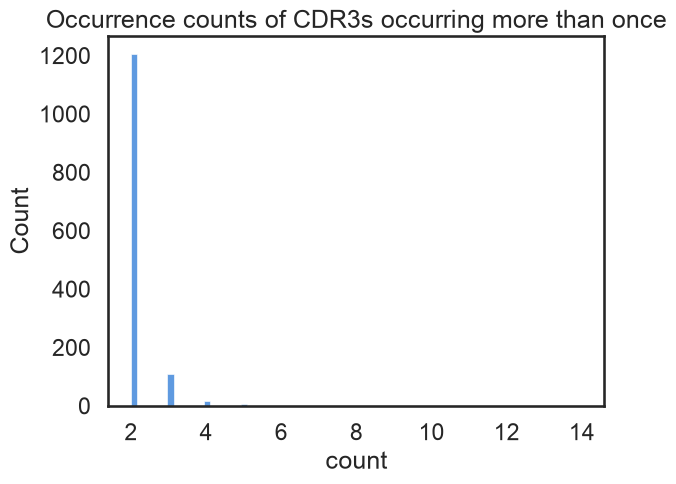

In [4]:
f, ax = plt.subplots()
sns.histplot(pdf_cmv_ecocluster_2026[pdf_cmv_ecocluster_2026.cdr3.isin(multiocc_tcrs)].cdr3.value_counts())
ax.set_title("Occurrence counts of CDR3s occurring more than once")

Mostly just twice, but with a long tail. Let's take a look at one that occurs several times.

In [5]:
pdf_cmv_ecocluster_2026[pdf_cmv_ecocluster_2026.cdr3 == multiocc_tcrs[1]][
    ["cdr3", "vgene", "jgene", "hla", "hla_cocluster"]]

cdr3       vgene       jgene         hla    hla_cocluster
4144   CASSWPGQGNTEAFF  TCRBV28-01  TCRBJ01-01  DRB3*02:02  h-DRB3_02_02-99
8645   CASSWPGQGNTEAFF  TCRBV18-01  TCRBJ01-01  DRB3*02:02  h-DRB3_02_02-99
12279  CASSWPGQGNTEAFF  TCRBV19-01  TCRBJ01-01  DRB3*02:02  h-DRB3_02_02-99
24754  CASSWPGQGNTEAFF  TCRBV14-01  TCRBJ01-01  DRB3*02:02  h-DRB3_02_02-99
35588  CASSWPGQGNTEAFF   TCRBV12-X  TCRBJ01-01  DRB3*02:02  h-DRB3_02_02-99
51378  CASSWPGQGNTEAFF  TCRBV07-06  TCRBJ01-01  DRB3*02:02  h-DRB3_02_02-99

Same J gene every time, same HLA association and HLA-COcluster... but 6 different V genes! CDR3s like that are rare, judging by the histogram above, but they do exist.

## How often do we see the same CDR3 with different J genes?


In [6]:
pdf_cmv_ecocluster_2026_multicdr3 = pdf_cmv_ecocluster_2026[
    pdf_cmv_ecocluster_2026.cdr3.isin(multiocc_tcrs)]


pdf_cdr3_jgene_counts = pdf_cmv_ecocluster_2026_multicdr3.groupby(['cdr3']).agg({
    "jgene": pd.Series.nunique}).reset_index()
print(f"Max number of different J genes for a single CDR3: {max(pdf_cdr3_jgene_counts['jgene'])}. Breakdown:")
pdf_cdr3_jgene_counts["jgene"].value_counts()


Max number of different J genes for a single CDR3: 3. Breakdown:


jgene
1    1298
2      41
3       1
Name: count, dtype: int64

So, it's very rare, but in 41 cases there's a pair of J genes with the same CDR3. In exactly one case, there are 3. Let's look at that one.

In [7]:
cdr3_3_j_genes = pdf_cdr3_jgene_counts[pdf_cdr3_jgene_counts.jgene == 3]['cdr3'].tolist()[0]
pdf_cmv_ecocluster_2026_multicdr3[pdf_cmv_ecocluster_2026_multicdr3.cdr3 == cdr3_3_j_genes][
    ["cdr3", "vgene", "jgene", "hla", "hla_cocluster"]]

cdr3       vgene       jgene      hla hla_cocluster
9446   CASSEATTQYF  TCRBV06-01  TCRBJ02-05  A*31:01  h-A_31_01-92
14051  CASSEATTQYF  TCRBV06-01  TCRBJ02-04  A*31:01  h-A_31_01-92
26518  CASSEATTQYF  TCRBV06-01  TCRBJ02-03  A*31:01  h-A_31_01-92

3 J genes, all in J family TCRBJ02, and the same V gene every time. Let's take a more comprehensive look at those 41 J-gene pairs.

In [8]:
cdr3s_2_jgenes = pdf_cdr3_jgene_counts[pdf_cdr3_jgene_counts.jgene == 2].cdr3.tolist()
pdf_cmv_ecocluster_2026_twoj = pdf_cmv_ecocluster_2026_multicdr3[
    pdf_cmv_ecocluster_2026_multicdr3.cdr3.isin(cdr3s_2_jgenes)]

pdf_cdr3_jgene_lists = pdf_cmv_ecocluster_2026_twoj.groupby(['cdr3']).agg({
    "jgene": list}).reset_index()
pdf_cdr3_jgene_lists["jgene"] = [sorted(jgenes) for jgenes in pdf_cdr3_jgene_lists.jgene]
pdf_cdr3_jgene_lists["jgene_a"], pdf_cdr3_jgene_lists["jgene_b"] = zip(*pdf_cdr3_jgene_lists.jgene)
pdf_cdr3_jgene_lists[["jgene_a", "jgene_b"]].value_counts()

jgene_a     jgene_b   
TCRBJ02-03  TCRBJ02-05    38
TCRBJ02-05  TCRBJ02-07     1
TCRBJ01-04  TCRBJ02-02     1
TCRBJ02-03  TCRBJ02-07     1
Name: count, dtype: int64

The same pair of Js accounting for 38 of 41 collisions among 13 J genes is vanishingly unlikely, on the face of it. But if those two are the most commonly-used J genes, then it'd be less unlikely. Let's see:

In [9]:
pdf_cmv_ecocluster_2026.jgene.value_counts()

jgene
TCRBJ02-07    7195
TCRBJ02-01    6489
TCRBJ01-01    6026
TCRBJ01-02    5716
TCRBJ02-03    5505
TCRBJ02-05    4615
TCRBJ01-05    4263
TCRBJ02-02    3636
TCRBJ01-06    2771
TCRBJ01-04    2622
TCRBJ01-03    2121
TCRBJ02-06     835
TCRBJ02-04     653
Name: count, dtype: int64

Nope, `J02-03` and `J02-05` are middle of the pack. I could set up a statistical test (I'll do that later on for V genes), but p would be effectively 0. But, to be thorough, let's look at the CDR3s that have those two J genes. If they all represent just one sequence cluster, maybe there's just a single binding solution that's open to either J gene. If they're very different, we're more likely looking at a broad phenomenon.


In [10]:
for cdr3 in sorted(list(cdr3s_2_jgenes), key=lambda x: len(x)):
    print(cdr3)

CASGRGTQYF
CASSAGSAQYF
CASSAGSTQYF
CASSLERTQYF
CASSPGSAQYF
CASSSGSAQYF
CASSSGSGQYF
CASSSGSTQYF
CASTSGSTQYF
CASRGTVGTQYF
CASRSTVGTQYF
CASRTTVGTQYF
CASSDQGVTQYF
CASSELGVTQYF
CASSFRRQTQYF
CAWSVNREAQYF
CASSDDRRGTQYF
CASSEVGQGTQYF
CASSGGTSGTQYF
CASSIERGGTQYF
CASSLEAEGTQYF
CASSLEVRGTQYF
CASSLGLKGTQYF
CASSLWGAGTQYF
CASSPDRRGTQYF
CASSQRTGRELFF
CASSVAREETQYF
CASSVARGETQYF
CASSVARSETQYF
CSVVTSGRGTQYF
CASSLDAGGGTQYF
CASSLNRGEGTQYF
CASSPGQAGGTQYF
CASSPGQGQGTQYF
CASSPQGGPGTQYF
CASSQAGSLGTQYF
CATSDSTPGGTQYF
CSASPGLAVGTQYF
CASSPGQGARGTQYF
CASSQDRGTLLTQYF
CASSVGQGARGTQYF


That's a wide variety of CDR3s. So, it seems likely that either:

* J gene caller is having trouble distinguishing between `J02-03` and `J02-05`
* `J02-03` and `J02-05` often bind with an HLA molecule to present a similar binding surface

Either way, we should probably treat those two J genes as equivalent for the purposes of ECOcluster matching.

**Takeaway**: `J02-03` and `J02-05` are a solid candidate for collapsing into a single J gene.

## How often do we see the same CDR3 with different V genes?


CDR3s with multiple V genes: n_cdr3s_multiv
TCRs with multi-V CDR3s: 2776 / 52447 (5.29%)
Max number of different V genes for a single CDR3: 14. Breakdown:


Text(0.5, 1.0, '# different V genes for a single CDR3 with 2+')

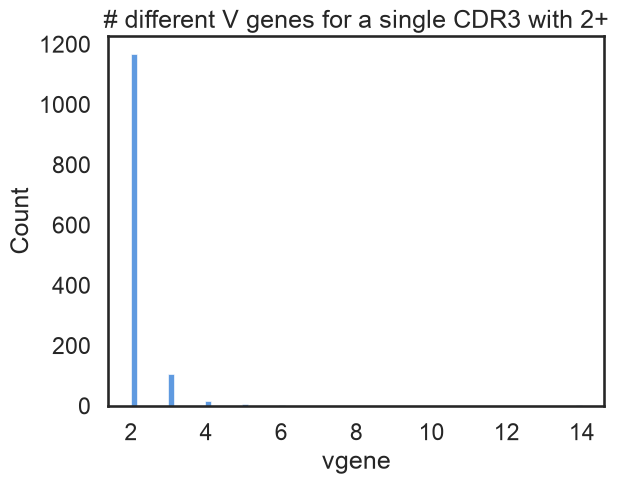

In [11]:
pdf_cdr3_vgene_counts = pdf_cmv_ecocluster_2026_multicdr3.groupby(['cdr3']).agg({
    "vgene": pd.Series.nunique}).reset_index()
pdf_cdr3_multivgene_counts = pdf_cdr3_vgene_counts[
    pdf_cdr3_vgene_counts.vgene > 1]
n_cdr3s_multiv = len(pdf_cdr3_multivgene_counts)
print(f"CDR3s with multiple V genes: n_cdr3s_multiv")

cdr3s_multi_vgenes = pdf_cdr3_jgene_counts[pdf_cdr3_vgene_counts.vgene > 1].cdr3.tolist()
pdf_cmv_ecocluster_2026_multiv = pdf_cmv_ecocluster_2026_multicdr3[
    pdf_cmv_ecocluster_2026_multicdr3.cdr3.isin(cdr3s_multi_vgenes)]
n_tcrs_multivcdr3 = len(pdf_cmv_ecocluster_2026_multiv)
print(f"TCRs with multi-V CDR3s: {n_tcrs_multivcdr3} / {len(pdf_cmv_ecocluster_2026)} ({100 * n_tcrs_multivcdr3 / len(pdf_cmv_ecocluster_2026):.2f}%)")



print(f"Max number of different V genes for a single CDR3: {max(pdf_cdr3_multivgene_counts['vgene'])}. Breakdown:")
f, ax = plt.subplots()
sns.histplot(pdf_cdr3_multivgene_counts["vgene"], ax=ax)
ax.set_title("# different V genes for a single CDR3 with 2+")

So, this is quite common! >5% of CMV ECOcluster TCRs are involved in one of these V-gene-mismatch cases. That suggests that dealing with this issue could increase sensitivity quite a bit when matching these TCRs to repertoires.

How often does this occur within vs. across V families?

In [12]:
# assemble the pairs
pdf_cdr3_vgene_lists = pdf_cmv_ecocluster_2026_multiv.groupby(['cdr3']).agg({
    "vgene": list}).reset_index()
pdf_cdr3_vgene_lists["vgene"] = [sorted(vgenes) for vgenes in pdf_cdr3_vgene_lists.vgene]
# explode all *pairs* of V genes for each CDR3.
pdf_all_cdr3_vgene_pairs = pdf_cdr3_vgene_lists.explode("vgene").merge(
    pdf_cdr3_vgene_lists.explode("vgene"), on="cdr3", suffixes=("_a", "_b"))
# pdf_all_cdr3_vgene_pairs contains two rows for each pair with different V genes.
# get rid of the one where vgene_a > vgene_b
pdf_cdr3_vgene_pairs = pdf_all_cdr3_vgene_pairs[
    (pdf_all_cdr3_vgene_pairs.vgene_a <= pdf_all_cdr3_vgene_pairs.vgene_b)]
# make vgene_a the lexicographically first of the two
pdf_cdr3_vgene_pairs["vgene_a"], pdf_cdr3_vgene_pairs["vgene_b"] = zip(*pdf_cdr3_vgene_pairs.apply(
    lambda x: sorted([x.vgene_a, x.vgene_b]), axis=1))
# drop any duplicates
pdf_cdr3_vgene_pairs = pdf_cdr3_vgene_pairs.drop_duplicates(["cdr3", "vgene_a", "vgene_b"])

#make a dataframe with just the different-V pairs
pdf_diff_cdr3_vgene_pairs = pdf_cdr3_vgene_pairs[
    pdf_cdr3_vgene_pairs.vgene_a < pdf_cdr3_vgene_pairs.vgene_b]


pdf_diff_cdr3_vgene_pairs["vfamily_a"] = pdf_diff_cdr3_vgene_pairs.vgene_a.apply(lambda x: x.split("-")[0])
pdf_diff_cdr3_vgene_pairs["vfamily_b"] = pdf_diff_cdr3_vgene_pairs.vgene_b.apply(lambda x: x.split("-")[0])
pdf_diff_cdr3_vgene_pairs["vfamily_agree"] = pdf_diff_cdr3_vgene_pairs.vfamily_a == pdf_diff_cdr3_vgene_pairs.vfamily_b
pdf_diff_cdr3_vgene_pairs["vfamily_agree"].value_counts().reset_index()

vfamily_agree  count
0           True   1131
1          False    626

In [13]:
pdf_diff_cdr3_vgene_pairs[pdf_diff_cdr3_vgene_pairs.cdr3 == "CSASPGLAVGTQYF"]

cdr3     vgene_a    vgene_b vfamily_a vfamily_b  vfamily_agree
5746  CSASPGLAVGTQYF  TCRBV20-01  TCRBV20-X   TCRBV20   TCRBV20           True

About 1/3 of the time, they have different V families. Let's look at the top V gene pairs that have different V families.

In [14]:
pdf_diff_cdr3_vgene_pairs[~pdf_diff_cdr3_vgene_pairs.vfamily_agree][["vgene_a", "vgene_b"]].value_counts()

vgene_a           vgene_b   
TCRBV05-01        TCRBV06-05    18
TCRBV07-02        TCRBV11-02    14
TCRBV05-01        TCRBV06-04    12
TCRBV07-08        TCRBV11-02    12
TCRBV07-02        TCRBV19-01    12
                                ..
TCRBV14-01        TCRBV28-01     1
TCRBV06-X         TCRBV12-X      1
TCRBV03-01/03-02  TCRBV12-05     1
TCRBV12-05        TCRBV27-01     1
TCRBV19-01        TCRBV24-01     1
Name: count, Length: 292, dtype: int64

When these conflicts are cross-V-family, they're not concentrated in a small number of V-gene or V-family pairs: the pair with the most conflicts has just 18 of 626. So, mismatch is primarily concentrated within a small number of pairs of V genes in the same V family. 

Let's see which V genes are most often involved in these cases. 

Top 10 V gene pairs with the same CDR3:


vgene_a           vgene_b  count
0          TCRBV20-01         TCRBV20-X    227
1          TCRBV07-06         TCRBV07-X    139
2          TCRBV07-02        TCRBV07-03     90
3          TCRBV06-02  TCRBV06-02/06-03     68
4          TCRBV06-05         TCRBV06-X     61
..                ...               ...    ...
343        TCRBV14-01        TCRBV28-01      1
344         TCRBV06-X         TCRBV12-X      1
345  TCRBV03-01/03-02        TCRBV12-05      1
346        TCRBV12-05        TCRBV27-01      1
347        TCRBV19-01        TCRBV24-01      1

[348 rows x 3 columns]

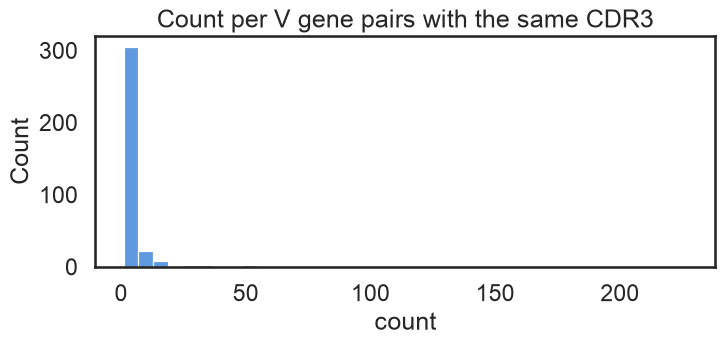

In [15]:
pdf_vgene_pair_counts = pdf_diff_cdr3_vgene_pairs[["vgene_a", "vgene_b"]].value_counts().reset_index()

f, ax = plt.subplots()
sns.histplot(pdf_vgene_pair_counts["count"], ax=ax)
ax.set_title("Count per V gene pairs with the same CDR3")
f.set_size_inches(8, 3)

print("Top 10 V gene pairs with the same CDR3:")

pdf_vgene_pair_counts

Several observations here:

* The top 15 V gene pairs (out of 348) are responsible for about half the mismatch
* It's very concentrated in the top few V gene pairs, always in the same V family
* A lot of the pairs have a member ending in "-X"
    * That just means the V gene could only be resolved to the V-family level
 
Let's see how often the pair contains an "-X" gene and then break out the "-X" and not-"-X" pairs separately.

In [16]:
pdf_diff_cdr3_vgene_pairs["has_x"] = pdf_diff_cdr3_vgene_pairs.apply(
    lambda x: "-X" in x.vgene_a or "-X" in x.vgene_b, axis=1)
display(pdf_diff_cdr3_vgene_pairs["has_x"].value_counts().reset_index())
print("No -X:")
display(pdf_diff_cdr3_vgene_pairs[~pdf_diff_cdr3_vgene_pairs.has_x][["vgene_a", "vgene_b"]].value_counts().reset_index())
print("Has -X:")
display(pdf_diff_cdr3_vgene_pairs[pdf_diff_cdr3_vgene_pairs.has_x][["vgene_a", "vgene_b"]].value_counts().reset_index())


has_x  count
0  False    976
1   True    781

No -X:


vgene_a           vgene_b  count
0          TCRBV07-02        TCRBV07-03     90
1          TCRBV06-02  TCRBV06-02/06-03     68
2          TCRBV06-05        TCRBV06-06     49
3          TCRBV07-02        TCRBV07-08     30
4          TCRBV06-01        TCRBV06-05     26
..                ...               ...    ...
269        TCRBV07-06        TCRBV14-01      1
270        TCRBV14-01        TCRBV28-01      1
271  TCRBV03-01/03-02        TCRBV12-05      1
272        TCRBV12-05        TCRBV27-01      1
273        TCRBV19-01        TCRBV24-01      1

[274 rows x 3 columns]

Has -X:


vgene_a     vgene_b  count
0         TCRBV20-01   TCRBV20-X    227
1         TCRBV07-06   TCRBV07-X    139
2         TCRBV06-05   TCRBV06-X     61
3         TCRBV07-02   TCRBV07-X     53
4         TCRBV07-07   TCRBV07-X     43
..               ...         ...    ...
69        TCRBV05-05   TCRBV06-X      1
70  TCRBV06-02/06-03   TCRBV12-X      1
71         TCRBV12-X  TCRBV14-01      1
72         TCRBV12-X  TCRBV18-01      1
73         TCRBV06-X   TCRBV12-X      1

[74 rows x 3 columns]

## Do all V genes get confused with [Vfamily]-X, or just some?

Is the observation here simply "sometimes we can't discern V gene, only family"? Or is the mismatch restricted to a subset of genes per family?

Let's look at the biggest offender, TCRBV20. How many TCRBV20 V genes are represented?

In [17]:
pdf_vgene_diffpair_counts_a = pdf_diff_cdr3_vgene_pairs.vgene_a.value_counts().reset_index()
pdf_vgene_diffpair_counts_a.columns = ["vgene", "count"]
pdf_vgene_diffpair_counts_b = pdf_diff_cdr3_vgene_pairs.vgene_b.value_counts().reset_index()
pdf_vgene_diffpair_counts_b.columns = ["vgene", "count"]
pdf_vgene_diffpair_counts_ab = pd.concat([pdf_vgene_diffpair_counts_a, pdf_vgene_diffpair_counts_b])
pdf_vgene_diffpair_counts = pdf_vgene_diffpair_counts_ab.groupby("vgene").agg({"count": "sum"}).reset_index().sort_values("count", ascending=False)
pdf_vgene_diffpair_counts.columns = ["vgene", "n_diff_pairs"]

pdf_vgene_counts = pdf_cmv_ecocluster_2026[["vgene", "vfamily"]].value_counts().reset_index()
pdf_vgene_counts.columns = ["vgene", "vfamily", "n_tcrs"]

pdf_vgene_counts_withdiffpairs = pdf_vgene_counts.merge(
    pdf_vgene_diffpair_counts, how="left", on="vgene").fillna(0)

pdf_vgene_counts_withdiffpairs["diffpairs_over_tcrs"] = (
    pdf_vgene_counts_withdiffpairs.n_diff_pairs / pdf_vgene_counts_withdiffpairs.n_tcrs)

pdf_vgene_counts_withdiffpairs[pdf_vgene_counts_withdiffpairs.vfamily == "TCRBV20"]

vgene  vfamily  n_tcrs  n_diff_pairs  diffpairs_over_tcrs
0    TCRBV20-X  TCRBV20    4018         227.0             0.056496
31  TCRBV20-01  TCRBV20     621         227.0             0.365539

Just one! And 100% of the mismatch involving TCRBV20-01 is with TCRBV20-X. So, in TCRBV20, it seems very clear we'd be better off just using V family.

How about TCRBV07?

In [18]:
pdf_vgene_counts_withdiffpairs[
    pdf_vgene_counts_withdiffpairs.vfamily == "TCRBV07"].sort_values("diffpairs_over_tcrs", ascending=False)

vgene  vfamily  n_tcrs  n_diff_pairs  diffpairs_over_tcrs
41   TCRBV07-X  TCRBV07     315         272.0             0.863492
43  TCRBV07-07  TCRBV07     222          84.0             0.378378
32  TCRBV07-06  TCRBV07     594         179.0             0.301347
28  TCRBV07-03  TCRBV07     665         129.0             0.193985
22  TCRBV07-08  TCRBV07     742         107.0             0.144205
5   TCRBV07-02  TCRBV07    2362         305.0             0.129128
9   TCRBV07-09  TCRBV07    1715          34.0             0.019825

There are several V07 V genes represented. The relative number of TCRs is quite different from how often they show up in the mismatch pairs, though. Let's place that within a broader context.

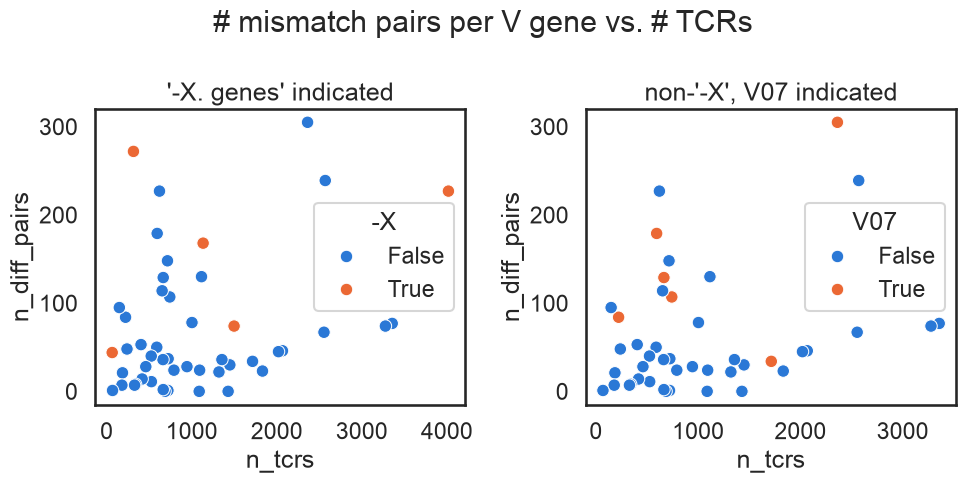

In [19]:
pdf_vgene_counts_withdiffpairs["-X"] = pdf_vgene_counts_withdiffpairs.vgene.str.endswith("-X")

f, (ax0, ax1) = plt.subplots(1, 2)
sns.scatterplot(x="n_tcrs", y="n_diff_pairs",
                data=pdf_vgene_counts_withdiffpairs, hue="-X", ax=ax0)
ax0.set_title("'-X. genes' indicated")

pdf_vgene_counts_withdiffpairs_nox = pdf_vgene_counts_withdiffpairs[~pdf_vgene_counts_withdiffpairs["-X"]]
pdf_vgene_counts_withdiffpairs_nox["V07"] = pdf_vgene_counts_withdiffpairs_nox.vgene.str.startswith("TCRBV07")

sns.scatterplot(x="n_tcrs", y="n_diff_pairs",
                data=pdf_vgene_counts_withdiffpairs_nox, hue="V07", ax=ax1)
ax1.set_title("non-'-X', V07 indicated")
f.suptitle("# mismatch pairs per V gene vs. # TCRs")
f.set_size_inches(10, 5)
f.tight_layout()



The "-X" genes (resolved at family level) are all involved in an outsized proportion of the mismatch pairs, as we've seen.

Most of the V07 genes are big outliers in how likely they are to be in mismatch pairs relative to their number of TCRs... but not `TCRBV07-09`. That V gene shows up quite often in the CMV ECOcluster but is rarely confused with another V gene.

Let's express the mismatch pairs as a fraction of the number of TCRs per V gene, and see if we're looking at just a few outliers, or what.



vgene  vfamily  n_tcrs  n_diff_pairs  diffpairs_over_tcrs  \
41         TCRBV07-X  TCRBV07     315         272.0             0.863492   
48         TCRBV11-X  TCRBV11      65          44.0             0.676923   
46        TCRBV06-02  TCRBV06     149          95.0             0.637584   
43        TCRBV07-07  TCRBV07     222          84.0             0.378378   
31        TCRBV20-01  TCRBV20     621         227.0             0.365539   
32        TCRBV07-06  TCRBV07     594         179.0             0.301347   
25        TCRBV06-06  TCRBV06     715         148.0             0.206993   
42        TCRBV11-01  TCRBV11     239          48.0             0.200837   
28        TCRBV07-03  TCRBV07     665         129.0             0.193985   
30  TCRBV06-02/06-03  TCRBV06     652         114.0             0.174847   

       -X  
41   True  
48   True  
46  False  
43  False  
31  False  
32  False  
25  False  
42  False  
28  False  
30  False

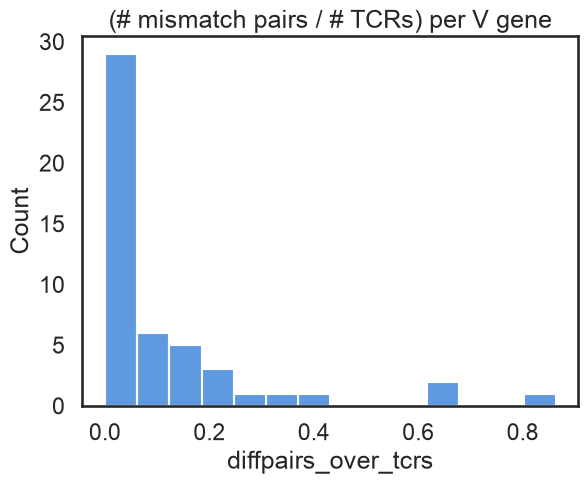

In [20]:
f, ax = plt.subplots()
sns.histplot(pdf_vgene_counts_withdiffpairs["diffpairs_over_tcrs"])
ax.set_title("(# mismatch pairs / # TCRs) per V gene")


pdf_vgene_counts_withdiffpairs.sort_values("diffpairs_over_tcrs", ascending=False)[:10]

Yep! We're just looking at a handful of outlier pairs of V genes.

## Adding a little statistical rigor

Let's put some statistics around this. For each pair of V genes with any shared CDR3s, we can ask whether they're enriched for shared CDR3s relative to their expected number of shared CDR3s (based on the count of CDR3-pair-members containing each member of the pair) if there was no enrichment. I'll use a one-sided Fisher's Exact Test for this, and then Bonferroni-correct for multiple testing.

15 V gene pairs survive Bonferroni correction at p<0.001


vgene_a           vgene_b  n_vgene_a  n_vgene_b  n_shared  \
0    TCRBV20-01         TCRBV20-X        227        227       227   
1    TCRBV07-06         TCRBV07-X        179        272       139   
3    TCRBV06-02  TCRBV06-02/06-03         95        114        68   
2    TCRBV07-02        TCRBV07-03        305        129        90   
9    TCRBV11-02         TCRBV11-X        130         44        31   
..          ...               ...        ...        ...       ...   
330  TCRBV06-05        TCRBV07-06        239        179         1   
232  TCRBV06-06        TCRBV07-02        148        305         1   
119   TCRBV06-X        TCRBV07-02        168        305         2   
228  TCRBV06-05         TCRBV07-X        239        272         1   
63   TCRBV06-05        TCRBV07-02        239        305         4   

          fisher_p  p_fisher_bonf  
0    7.568311e-293  2.633772e-290  
1     3.859408e-91   1.343074e-88  
3     7.112069e-69   2.475000e-66  
2     1.204637e-43   4.192137e-41  
9     5.753066e-27   2.002067e-24  
..             ...            ...  
330   1.000000e+00   3.480000e+02  
232   1.000000e+00   3.480000e+02  
119   1.000000e+00   3.480000e+02  
228   1.000000e+00   3.480000e+02  
63    1.000000e+00   3.480000e+02  

[348 rows x 7 columns]

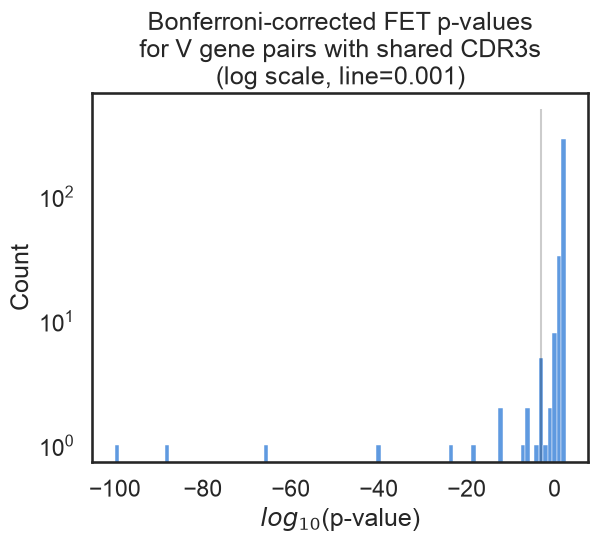

In [21]:
from scipy.stats import fisher_exact
import numpy as np

def fisher_test_vgene_pair(row, pdf_cdr3_vgene_pairs):
    vgene_a = row['vgene_a']
    vgene_b = row['vgene_b']
    n_vgene_a = sum((pdf_cdr3_vgene_pairs.vgene_a == vgene_a) |
                    (pdf_cdr3_vgene_pairs.vgene_b == vgene_a))
    n_vgene_b = sum((pdf_cdr3_vgene_pairs.vgene_a == vgene_b) |
                    (pdf_cdr3_vgene_pairs.vgene_b == vgene_b))
    n_shared = row["count"]

    # calculate a Fisher's Exact Test p-value 
    n_total_pairs = len(pdf_cdr3_vgene_pairs)
    fisher_p = fisher_exact([[n_shared, n_vgene_a - n_shared],
                                 [n_vgene_b - n_shared, n_total_pairs - n_vgene_a - n_vgene_b + n_shared]],
                                alternative='greater')[1]
    return fisher_p

def test_all_vgene_pairs(pdf_vgenepair_counts_diff, pdf_cdr3_vgene_pairs):
    rows = []
    for _, row in pdf_vgenepair_counts_diff.iterrows():
        vgene_a = row['vgene_a']
        vgene_b = row['vgene_b']
        if vgene_a == vgene_b:
            continue  # Skip pairs where both V genes are the same

        n_vgene_a = sum((pdf_cdr3_vgene_pairs.vgene_a == vgene_a) |
                        (pdf_cdr3_vgene_pairs.vgene_b == vgene_a))
        n_vgene_b = sum((pdf_cdr3_vgene_pairs.vgene_a == vgene_b) |
                        (pdf_cdr3_vgene_pairs.vgene_b == vgene_b))
        n_shared = row["count"]

        # calculate a Fisher's Exact Test p-value 
        n_total_pairs = len(pdf_cdr3_vgene_pairs)
        fisher_p = fisher_exact([[n_shared, n_vgene_a - n_shared],
                                     [n_vgene_b - n_shared, n_total_pairs - n_vgene_a - n_vgene_b + n_shared]],
                                    alternative='greater')[1]

        rows.append({
            "vgene_a": vgene_a,
            "vgene_b": vgene_b,
            "n_vgene_a": n_vgene_a,
            "n_vgene_b": n_vgene_b,
            "n_shared": n_shared,
            "fisher_p": fisher_p
        })
    pdf_result = pd.DataFrame(rows).sort_values('fisher_p')
    pdf_result["p_fisher_bonf"] = pdf_result.fisher_p * len(pdf_result)
    # add a small epsilon when taking the log in case of underflow and p=0
    pdf_result["log10_p"] = np.log10(pdf_result.p_fisher_bonf + 1e-100)

    return pdf_result


pdf_vgenepair_counts = pdf_diff_cdr3_vgene_pairs[["vgene_a", "vgene_b"]].value_counts().reset_index()
pdf_vgenepair_counts_diff = pdf_vgenepair_counts[pdf_vgenepair_counts.vgene_a != pdf_vgenepair_counts.vgene_b]

pdf_vgenepair_pvalues = test_all_vgene_pairs(pdf_vgenepair_counts_diff, pdf_diff_cdr3_vgene_pairs)

thresh_bonf = .001


f, ax = plt.subplots()
sns.histplot(pdf_vgenepair_pvalues["log10_p"], bins=100)
# add vertical line at x=log10(thresh_bonf)
sns.lineplot(x=[np.log10(thresh_bonf), np.log10(thresh_bonf)], y=[0, 500], color="black", ax=ax,
            linestyle="dashed")
ax.set_yscale("log")
ax.set_title(f"Bonferroni-corrected FET p-values\nfor V gene pairs with shared CDR3s\n(log scale, line={thresh_bonf})")
ax.set_xlabel("${log}_{10}$(p-value)")

pdf_vgenepair_pvalues_signif = pdf_vgenepair_pvalues[
    pdf_vgenepair_pvalues.p_fisher_bonf < thresh_bonf]
print(f"{len(pdf_vgenepair_pvalues_signif)} V gene pairs survive Bonferroni correction at p<{thresh_bonf}")


pdf_vgenepair_pvalues.drop(columns=["log10_p"])

So, being a little extra cautious, 15 pairs of V genes survive Bonferroni correction at p<0.001. All but one of those pairs are in the same V family. 6 involve a "-X" gene (V20, V07, V11 and V06). 

One of those things is not like the others: `{'TCRBV05-01', 'TCRBV06-04'}`. Those two V genes are in different V families. Let's take a closer look.

In [22]:
pdf_vgenepair_pvalues[(pdf_vgenepair_pvalues.vgene_a == "TCRBV05-01") & (pdf_vgenepair_pvalues.vgene_b == "TCRBV06-04")]

vgene_a     vgene_b  n_vgene_a  n_vgene_b  n_shared      fisher_p  \
21  TCRBV05-01  TCRBV06-04         74         53        12  8.497749e-07   

    p_fisher_bonf   log10_p  
21       0.000296 -3.529117

That pair of V genes just barely survives Bonferroni correction at p<0.001. The number of shared CDR3s is 12, which is quite low among pairs that survive Bonferroni correction (see above). 

As we did above with the J gene pair, let's see what those 12 CDR3s look like.

In [23]:
n_5_1 = sum((pdf_cdr3_vgene_pairs.vgene_a == "TCRBV05-01") |
            (pdf_cdr3_vgene_pairs.vgene_b == "TCRBV05-01"))
n_6_4 = sum((pdf_cdr3_vgene_pairs.vgene_a == "TCRBV06-04") |
            (pdf_cdr3_vgene_pairs.vgene_b == "TCRBV06-04"))

pdf_5_1_6_4 = pdf_diff_cdr3_vgene_pairs[((pdf_diff_cdr3_vgene_pairs.vgene_a == "TCRBV05-01") & (pdf_diff_cdr3_vgene_pairs.vgene_b == "TCRBV06-04")) |
              ((pdf_diff_cdr3_vgene_pairs.vgene_a == "TCRBV06-04") & (pdf_diff_cdr3_vgene_pairs.vgene_b == "TCRBV05-01"))
]
for cdr3 in sorted(list(pdf_5_1_6_4.cdr3)):
    print(cdr3)

CASKKQGAADTQYF
CASRKQGAADTQYF
CASRKQGAGDTQYF
CASRKQGATDTQYF
CASRKQGSADTQYF
CASRKQGSSDTQYF
CASRKQGSTDTQYF
CASRKQGVTDTQYF
CASRLQGAGDTQYF
CASRLQGGTDTQYF
CASRLQGSTDTQYF
CASRLQGTTDTQYF


That looks like just a single binding solution with 12 TCRs: they're all a single edit from another member of the group, i.e., a single connected component in a graph where edges are 1-edit differences. That makes me nervous about combining those V genes: it could be that this one binding solution works with either of those V genes, but this binding solution is an outlier that doesn't represent a general trend.

Let's check all the other V gene pairs that survive Bonferroni correction: for each surviving V gene pair, build a graph on single edit distances and see how many connected components there are.

vgene_a           vgene_b  n_shared_cdr3s  \
12  TCRBV05-01        TCRBV06-04              12   
13  TCRBV04-01        TCRBV04-03               7   
9   TCRBV04-01        TCRBV04-02               9   
10  TCRBV11-01        TCRBV11-02              18   
5   TCRBV04-02        TCRBV04-03              17   
11  TCRBV06-01        TCRBV06-06              22   
14  TCRBV06-06         TCRBV06-X              33   
4   TCRBV11-02         TCRBV11-X              31   
8   TCRBV06-05        TCRBV06-06              49   
7   TCRBV07-07         TCRBV07-X              43   
6   TCRBV06-05         TCRBV06-X              61   
2   TCRBV06-02  TCRBV06-02/06-03              68   
3   TCRBV07-02        TCRBV07-03              90   
1   TCRBV07-06         TCRBV07-X             139   
0   TCRBV20-01         TCRBV20-X             227   

             unique_cdr3_lengths  n_ccs  
12                          {14}      1  
13                  {16, 18, 15}      5  
9                   {16, 17, 15}      8  
10              {16, 13, 14, 15}     15  
5   {12, 13, 14, 15, 16, 17, 18}     17  
11          {11, 12, 13, 14, 15}     21  
14  {12, 13, 14, 15, 16, 17, 19}     22  
4   {11, 13, 14, 15, 16, 17, 18}     23  
8           {12, 13, 14, 15, 16}     28  
7                   {12, 13, 14}     33  
6   {10, 11, 12, 13, 14, 15, 16}     43  
2       {11, 12, 13, 14, 15, 16}     55  
3   {12, 13, 14, 15, 16, 17, 18}     63  
1               {11, 12, 13, 14}     83  
0       {12, 13, 14, 15, 16, 17}    110

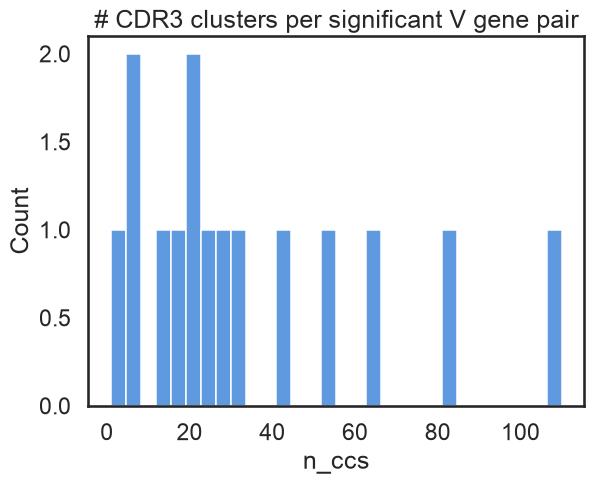

In [24]:
from cmvividly.data.hamming1_graph import build_seq_ham1_graph_and_extract_ccs

rows = []
for _, row in pdf_vgenepair_pvalues_signif.iterrows():
    vgene_a = row['vgene_a']
    vgene_b = row['vgene_b']
    pdf_pairs_this_pair = pdf_diff_cdr3_vgene_pairs[
        ((pdf_diff_cdr3_vgene_pairs.vgene_a == vgene_a) & (pdf_diff_cdr3_vgene_pairs.vgene_b == vgene_b)) |
        ((pdf_diff_cdr3_vgene_pairs.vgene_a == vgene_b) & (pdf_diff_cdr3_vgene_pairs.vgene_b == vgene_a))
    ]
    unique_cdr3_lengths = set(pdf_pairs_this_pair.cdr3.apply(len))
    
    # find connected components in a graph defined Hamming-1 distances between those CDR3s
    pdf_ccs = build_seq_ham1_graph_and_extract_ccs(pdf_pairs_this_pair)
    n_ccs = len(set(pdf_ccs.connected_component))

    rows.append({
        "vgene_a": vgene_a,
        "vgene_b": vgene_b,
        "n_shared_cdr3s": row["n_shared"],
        "unique_cdr3_lengths": unique_cdr3_lengths,
        "n_ccs": n_ccs
    })
pdf_vgenepair_cdr3_lengths = pd.DataFrame(rows).sort_values("n_shared_cdr3s", ascending=False)


f, ax = plt.subplots()
sns.histplot(pdf_vgenepair_cdr3_lengths["n_ccs"], ax=ax, bins=30)
ax.set_title("# CDR3 clusters per significant V gene pair")


pdf_vgenepair_cdr3_lengths.sort_values("n_ccs")


Aha! All the other V gene pairs have at least 5 connected components represented. One has more than 100! So, `{'TCRBV05-01', 'TCRBV06-04'}` is the worst-supported pair in that sense, *and* the only cross-V-family pair.

I'll strip that pair from the significant V gene pairs and move forward with the rest.

In [25]:
pdf_vgenepair_pvalues_retained = pdf_vgenepair_pvalues_signif[
    ~((pdf_vgenepair_pvalues_signif.vgene_a == "TCRBV05-01") & (pdf_vgenepair_pvalues_signif.vgene_b == "TCRBV06-04")) &
    ~((pdf_vgenepair_pvalues_signif.vgene_a == "TCRBV06-04") & (pdf_vgenepair_pvalues_signif.vgene_b == "TCRBV05-01"))
]
print(f"{len(pdf_vgenepair_pvalues_retained)} V gene pairs retained after removing TCRBV05-01/TCRBV06-04")

14 V gene pairs retained after removing TCRBV05-01/TCRBV06-04


## Extract groups of V genes that should be considered indistinguishable

Most of these are small clusters of pairs, not just isolated pairs, so let's visualize this.

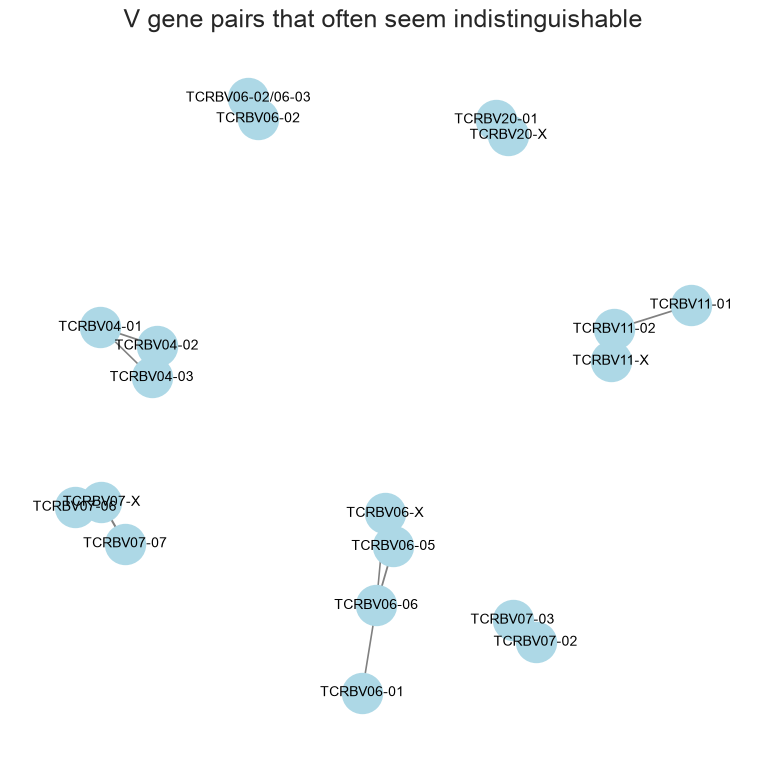

In [26]:
# use networkx to visualize the V gene pairs that survive Bonferroni correction
from networkx import Graph
import networkx as nx

def build_pvalue_graph(pdf_vgenepair_pvalues_signif):
    G = Graph()
    for _, row in pdf_vgenepair_pvalues_signif.iterrows():
        G.add_edge(row['vgene_a'], row['vgene_b'], weight=-row['log10_p'])
    return G

def visualize_pvalue_graph(G):
    f, ax = plt.subplots()
    pos = nx.spring_layout(G, seed=42, k=0.8)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    max_weight = max(edge_weights) if edge_weights else 1
    edge_widths = [1 + 4 * (w / max_weight) for w in edge_weights]

    nx.draw_networkx_nodes(G, pos, node_size=800, node_color="lightblue", ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color="gray", ax=ax)

    edge_labels = {(u, v): f"{G[u][v]['weight']:.1f}" for u, v in G.edges()}

    ax.set_title("V gene pairs that often seem indistinguishable")
    ax.axis("off")
    f.set_size_inches(8, 8)
    f.tight_layout()

G = build_pvalue_graph(pdf_vgenepair_pvalues_retained)
visualize_pvalue_graph(G)

We've got groups sizes 2, 3 and 4. Let's extract the connected components of that graph.

In [27]:
# extract connected components
vgene_clusters = list(nx.connected_components(G))
vgene_clusters

[{'TCRBV20-01', 'TCRBV20-X'},
 {'TCRBV07-06', 'TCRBV07-07', 'TCRBV07-X'},
 {'TCRBV06-02', 'TCRBV06-02/06-03'},
 {'TCRBV07-02', 'TCRBV07-03'},
 {'TCRBV11-01', 'TCRBV11-02', 'TCRBV11-X'},
 {'TCRBV04-01', 'TCRBV04-02', 'TCRBV04-03'},
 {'TCRBV06-01', 'TCRBV06-05', 'TCRBV06-06', 'TCRBV06-X'}]

## What to do with this information

I think treating those pairs of V genes each as a single V gene is a pretty reasonable thing to do when applying the CMV ECOcluster TCRs to Adaptive data. Maybe even when using Adaptive data in general.

What does that mean practically? Well, if you're working with Adaptive repertoire data, and you've got a TCR with one of those V genes that otherwise (CDR3 and J) matches to a CMV ECOcluster TCR with the other, you should probably treat it as a match.

To facilitate that kind of matching, I made a library routine, `combine_indistinguishable_genes`, that takes a dataframe of TCRs and returns a new dataframe with those genes combined using the mappings above: 7 groups of V genes and one group of two J genes.

Let's apply that method to the CMV ECOclsuter TCRs and see how many TCRs we end up with.



In [28]:
from cmvividly.data.combine_v_j_groups import combine_indistinguishable_genes

pdf_cmv_ecocluster_2026_combinedvj = combine_indistinguishable_genes(
    pdf_cmv_ecocluster_2026, drop_original_gene_cols=False, retain_original_tcr=True).drop_duplicates("tcr")

print(f"Original CMV ECOcluster TCRs: {len(pdf_cmv_ecocluster_2026)}")
print(f"CMV ECOcluster TCRs after combining V/J groups: {len(pdf_cmv_ecocluster_2026_combinedvj)}")

Original CMV ECOcluster TCRs: 52447
CMV ECOcluster TCRs after combining V/J groups: 51618


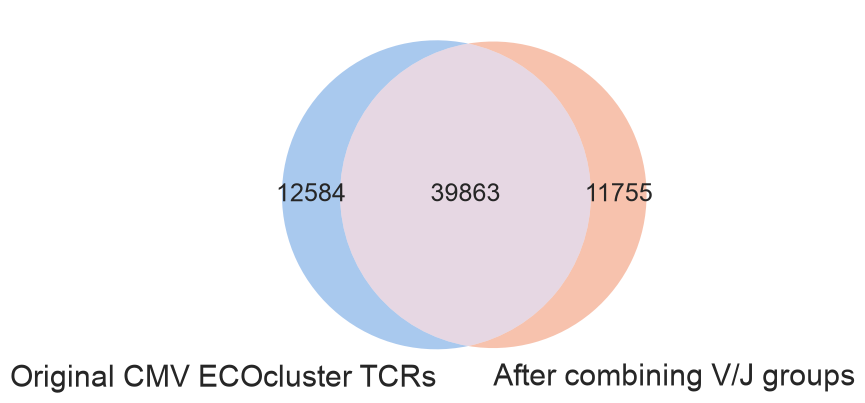

In [30]:
from matplotlib_venn import venn2
venn2([set(pdf_cmv_ecocluster_2026.tcr), set(pdf_cmv_ecocluster_2026_combinedvj.tcr)],
      set_labels=("Original CMV ECOcluster TCRs", "After combining V/J groups"))
